# Chapter 1 · Section 1.3
# An Example: Kermack–McKendrick Model

**Source:** Li, M.Y. (2018), pp. 8–11.

This section takes the abstract ODE structure derived in Section 1.2 and fills in every rate term
with a concrete hypothesis, producing the first fully explicit epidemic model in the book — and
then extracts real, checkable predictions from it, including the famous **epidemic threshold**.


---
## Block 1 — Seven hypotheses that define the model

### 1. Rewrite

To turn the general balance equations of Sec. 1.2 into an explicit model, the book makes seven
hypotheses about disease transmission and the host population:

1. Transmission is horizontal, via direct contact between hosts (no vertical/mother-to-child
   transmission considered).
2. Mixing is homogeneous ("Law of Mass Action"): the number of contacts between two compartments
   depends only on the sizes of those compartments. Concretely, the incidence rate (new infections
   per unit time) is $\lambda I(t) S(t)$, where $\lambda$ is the transmission coefficient.
3. Transfer out of a compartment is proportional to that compartment's size — e.g. the recovery
   rate (transfer from $I$ to $R$) is $\gamma I(t)$, for rate constant $\gamma$.
4. Infected individuals become infectious immediately — no latency period.
5. Immunity, once acquired, never wanes — no reinfection, so transfer from $R$ back to $S$ is zero.
6. No new susceptibles enter, and there's no removal (death/migration) from any compartment.
7. Consequently, the total population is constant — this follows from (6) but is stated separately
   for emphasis.

The book notes these look restrictive but are quite plausible for, e.g., an outbreak confined to a
university campus over a single semester (short timescale ⟹ no births/deaths/migration; simple
short-lived infections ⟹ no latency, no waning immunity).

### 2. Simplified

Imagine setting rules for a game of tag on a playground, to make it simple enough to actually
predict who gets tagged:

1. You only get tagged by someone touching you directly (no tagging from far away).
2. Everyone mixes randomly in the same playground — no cliques who never interact.
3. The chance any one "it" kid tags someone in the next minute depends only on how many kids are
   still "not it."
4. The moment you're tagged, you're immediately "it" too — no delay.
5. Once you've been "it" and then get un-tagged (sit out), you can never play as "not it" again —
   you're just done for the game.
6. Nobody new joins the game partway through, and nobody leaves early.
7. So the total number of kids playing never changes.

These are simplifying rules — real playgrounds are messier — but they make the game's outcome
something you can actually predict with math, which is the whole point.

### 3. Key Ideas

| Hypothesis | Mathematical consequence |
|---|---|
| (1)+(2) Mass action | Incidence rate $= \lambda I(t) S(t)$ — the single most important modeling choice in this whole model |
| (3) Proportional transfer | Recovery rate $=\gamma I(t)$ — linear/first-order kinetics |
| (4) No latency | Model needs only $S,I,R$ — no "exposed" compartment (contrast with SEIR in Ch. 5) |
| (5) Permanent immunity | No arrow from $R$ back to $S$ — simplifies the transfer diagram from Fig. 1.1 |
| (6)+(7) Closed population | $N(t)=S(t)+I(t)+R(t)$ is constant — this becomes a provable *conservation law*, not just an assumption, once we have the ODEs |

### 6. Mathematical Intuition

Hypothesis (2) is the single most consequential assumption in the whole model, and it's worth
sitting with why $\lambda I S$ (a *product*) is the natural form. If contacts are homogeneous
("mass action," borrowed directly from chemical kinetics), then the chance any *one* susceptible
person meets an infectious person in a short time is proportional to $I(t)$ (more infectious
people ⟹ more chances to meet one), and the *total* number of new infections scales with how many
susceptible people there are to begin with, i.e. proportional to $S(t)$ too. Two independent
proportionalities multiplied together give a bilinear term $\lambda I(t) S(t)$ — this is exactly
the same functional form as the law of mass action in chemistry, where reaction rate is
proportional to the product of reactant concentrations.


---
## Block 2 — The explicit Kermack–McKendrick ODE system

### 1. Rewrite

Substituting the hypotheses into the general balance equations (1.2) from Sec. 1.2 — with zero
influx of new susceptibles, zero transfer from $R$ to $S$, zero removal from any compartment —
gives:

$$\frac{dS}{dt} = -\lambda I S \qquad (1.3)$$
$$\frac{dI}{dt} = \lambda I S - \gamma I \qquad (1.4)$$
$$\frac{dR}{dt} = \gamma I \qquad (1.5)$$

with initial conditions $S(0)=S_0>0$, $I(0)=I_0>0$, $R(0)=0$.

$S,I,R$ are **state variables** (must be non-negative — they're counts of people). $\lambda,
\gamma$ are **model parameters** (non-negative rate constants). Given $\lambda,\gamma,S_0,I_0$,
this system has a unique solution for $t>0$ — it makes a genuine, checkable prediction for how the
epidemic unfolds.

### 4. Mathematical Breakdown — deriving (1.3)–(1.5) from (1.2) term by term

Recall the general form from Sec. 1.2:
$$S'(t) = \text{influx of new susceptibles} + \text{transfer rate from } R - \text{incidence rate} - \text{removal rate from } S$$

Substitute each term using the seven hypotheses:
- influx of new susceptibles $= 0$ (Hyp. 6)
- transfer rate from $R$ $= 0$ (Hyp. 5: no waning immunity)
- incidence rate $= \lambda I(t) S(t)$ (Hyp. 2)
- removal rate from $S$ $= 0$ (Hyp. 6)

$$\Rightarrow \quad S'(t) = 0 + 0 - \lambda I(t) S(t) - 0 = -\lambda I(t) S(t)$$

which is exactly (1.3). Repeating for $I$:
$$I'(t) = \underbrace{\lambda I(t) S(t)}_{\text{incidence rate, Hyp. 2}} - \underbrace{\gamma I(t)}_{\text{transfer rate into } R\text{, Hyp. 3}} - \underbrace{0}_{\text{removal, Hyp. 6}} = \lambda IS - \gamma I$$
which is (1.4). And for $R$:
$$R'(t) = \underbrace{\gamma I(t)}_{\text{transfer from } I} - \underbrace{0}_{\text{transfer into }S\text{, Hyp. 5}} - \underbrace{0}_{\text{removal, Hyp. 6}} = \gamma I$$
which is (1.5). Every term in (1.3)–(1.5) traces back to exactly one hypothesis — nothing is
added or dropped without justification.

### 5. Symbols

| Symbol | Meaning | Units | What happens if it changes |
|---|---|---|---|
| $\lambda$ | Transmission coefficient | 1/(person·time) | Larger $\lambda$ ⟹ faster spread for the same $S,I$ |
| $\gamma$ | Recovery rate constant | 1/time | Larger $\gamma$ ⟹ people leave $I$ faster (shorter average infectious period $1/\gamma$) |
| $S_0, I_0$ | Initial susceptible/infectious counts | people | Sets the starting point of the epidemic; $R_0^{\text{count}}=0$ always (no one has recovered yet at $t=0$) — careful: this "$R(0)=0$" is *not* the same symbol as the famous reproduction number $\mathcal{R}_0$! |

### 7. Visual Understanding


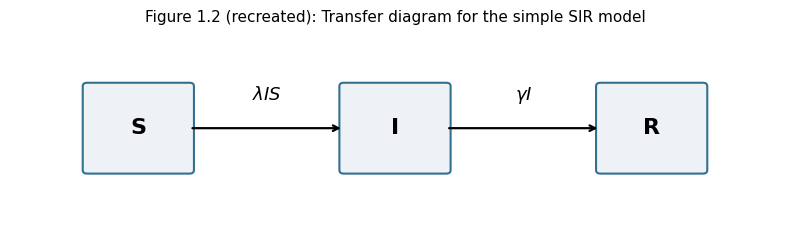

In [1]:
# Figure 1.2 (recreated): explicit transfer diagram with rate labels on the arrows
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.set_xlim(0, 9)
ax.set_ylim(0, 3)
ax.axis("off")

compartments = {"S": 1.5, "I": 4.5, "R": 7.5}
for label, x in compartments.items():
    ax.add_patch(patches.FancyBboxPatch((x-0.6, 1.0), 1.2, 1.2, boxstyle="round,pad=0.05",
                                         fc="#eef2f7", ec="#31708f", lw=1.5))
    ax.text(x, 1.6, label, ha="center", va="center", fontsize=16, fontweight="bold")

ax.annotate("", xy=(3.9, 1.6), xytext=(2.1, 1.6), arrowprops=dict(arrowstyle="->", lw=1.6))
ax.text(3.0, 2.0, r"$\lambda I S$", ha="center", fontsize=13)
ax.annotate("", xy=(6.9, 1.6), xytext=(5.1, 1.6), arrowprops=dict(arrowstyle="->", lw=1.6))
ax.text(6.0, 2.0, r"$\gamma I$", ha="center", fontsize=13)

ax.set_title("Figure 1.2 (recreated): Transfer diagram for the simple SIR model", fontsize=11)
plt.tight_layout()
plt.savefig("transfer_diagram_1_2.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Block 3 — Provable properties of the model, without solving it explicitly

### 1. Rewrite

Even without knowing $\lambda,\gamma$'s specific values, three qualitative facts can be proven
directly from the equations:

**(a) Total population is conserved.** Let $N(t)=S(t)+I(t)+R(t)$. Adding (1.3)+(1.4)+(1.5):
$dN/dt = 0$, so $N(t)=N_0=S_0+I_0$ for all $t$.

**(b) $S(t)$ is always non-increasing.** From (1.3), $dS/dt = -\lambda I S \le 0$ (since $\lambda,
I,S \ge 0$), so $S(t) \le S_0$ for all $t\ge 0$.

**(c) The epidemic threshold.** Rewrite (1.4) as $I'(t) = (\lambda S(t) - \gamma) I(t)$. Two
cases:
- If $S_0 < \gamma/\lambda$: since $S(t)\le S_0 < \gamma/\lambda$ for all $t$ (by fact (b)),
  $I'(t) < 0$ always, so $I(t)$ strictly decreases from the start — **no epidemic occurs**.
- If $S_0 > \gamma/\lambda$: then $S(t) > \gamma/\lambda$ holds on some initial interval
  $[0,\bar t)$, so $I'(t) > 0$ there, and $I(t)$ strictly increases — **an epidemic happens**.

So $\gamma/\lambda$ is a **threshold value**: $S_0$ must exceed it for an epidemic to take off.
This is often called the **critical community size**.

### 2. Simplified

**(a)** is just "nobody's created or destroyed" — kids only move between rooms, the school's total
enrollment doesn't change.

**(b)** says the "Can Still Catch It" room can only ever lose kids (to infection) — it never
magically gains any back, because nobody re-enters it once infected (Hyp. 5: no waning immunity).
It's a one-way door.

**(c)** is the deepest idea in this section. Imagine each infectious kid can, on average, either
"more than replace themselves" by infecting more than one new kid before recovering, or "less than
replace themselves." Whether they do depends on how many susceptible kids ($S_0$) are around to
catch it from them, versus how quickly they'd recover ($\gamma$) and how contagious they are
($\lambda$). If there simply aren't enough susceptible kids around ($S_0$ small), even a
contagious kid can't find enough people to infect before recovering — the "rumor" fizzles
immediately. But if there are plenty of susceptible kids ($S_0$ large), it takes off. The number
$\gamma/\lambda$ is the exact tipping point between "fizzles" and "takes off."

### 3. Key Ideas

- **Conservation law** $N(t)=N_0$ — a *proof*, not an assumption (it follows algebraically from
  adding all three equations), even though it traces back to Hypothesis 7.
- **Monotonicity of $S(t)$** — a one-line sign argument from the ODE itself, needing no
  simulation.
- **Threshold phenomenon**: existence of $\gamma/\lambda$ as a critical value of $S_0$ — this is
  the conceptual seed of the basic reproduction number $\mathcal{R}_0$, formally defined in later
  chapters as $\mathcal{R}_0 = \lambda S_0/\gamma$ (epidemic ⟺ $\mathcal{R}_0 > 1$).
- The book explicitly flags this as "the power... of mathematical analysis" — extracting exact,
  provably-true qualitative statements *without* needing to know parameter values or solve the
  system explicitly.

### 4. Mathematical Breakdown — the threshold argument in full

**Step 1.** Add (1.3), (1.4), (1.5):
$$\frac{dS}{dt}+\frac{dI}{dt}+\frac{dR}{dt} = (-\lambda IS) + (\lambda IS - \gamma I) + (\gamma I) = 0.$$
Every term cancels — $-\lambda IS$ cancels with $+\lambda IS$, and $-\gamma I$ cancels with
$+\gamma I$. Since $\frac{d}{dt}(S+I+R) = \frac{dN}{dt} = 0$, $N(t)$ is constant, $=N_0$.

**Step 2.** From (1.3) directly: $\lambda, I(t), S(t) \ge 0$ for all $t$ (they're rates and
population counts), so their product $\lambda I(t) S(t) \ge 0$, hence $dS/dt = -\lambda IS \le 0$.
A function with non-positive derivative everywhere is non-increasing, so $S(t) \le S(0) = S_0$.

**Step 3.** Factor (1.4): $I'(t) = \lambda S(t) I(t) - \gamma I(t) = I(t)\big(\lambda S(t) -
\gamma\big) = (\lambda S(t) - \gamma) I(t)$. Since $I(t) > 0$ throughout (as long as any infectious
individuals remain), the **sign of $I'(t)$ is entirely determined by the sign of
$(\lambda S(t) - \gamma)$**.

**Step 4 — Case (i): $S_0 < \gamma/\lambda$.** By Step 2, $S(t)\le S_0 < \gamma/\lambda$ for all
$t \ge 0$, i.e. $\lambda S(t) < \gamma$, i.e. $\lambda S(t) - \gamma < 0$ for all $t$. By Step 3,
$I'(t) < 0$ for all $t \ge 0$: $I$ is strictly decreasing from the very first instant, so no growth
phase ever occurs.

**Step 5 — Case (ii): $S_0 > \gamma/\lambda$.** At $t=0$, $S(0)=S_0 > \gamma/\lambda$, i.e.
$\lambda S(0) - \gamma > 0$. Since $S(t)$ is continuous (in fact differentiable), by continuity
there is some $\bar t > 0$ such that $S(t) > \gamma/\lambda$ still holds for $t\in[0,\bar t)$. On
that interval, by Step 3, $I'(t) > 0$: $I$ strictly increases — an epidemic (a growth phase)
occurs.

**Step 6 — conclusion.** $\gamma/\lambda$ is a genuine threshold for $S_0$: below it, no epidemic;
above it, an epidemic occurs. This threshold falls directly out of the sign analysis of a single
algebraic factor $(\lambda S - \gamma)$ — no need to solve the ODE system explicitly.


Threshold value gamma/lambda = 400.0
below threshold (no epidemic): S0=250, peak I(t) = 5.0 (I0 was 5) -> never exceeded I0
above threshold (epidemic): S0=550, peak I(t) = 27.6 (I0 was 5) -> GREW


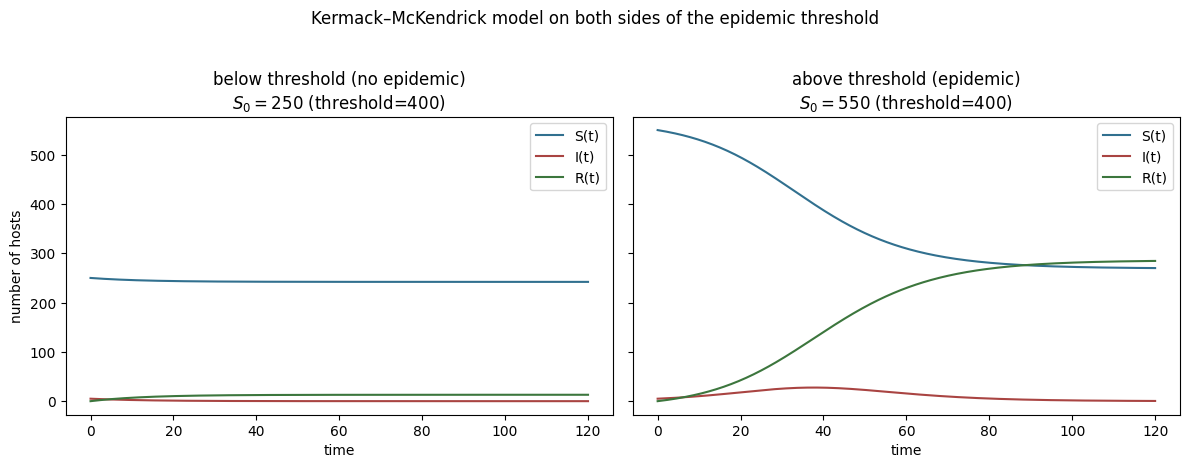

In [2]:
# Numerically verifying the threshold theorem by actually solving the ODEs
# on both sides of the threshold, using scipy's solve_ivp.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def kermack_mckendrick(t, y, lam, gamma):
    S, I, R = y
    dS = -lam * I * S
    dI = lam * I * S - gamma * I
    dR = gamma * I
    return [dS, dI, dR]

lam = 0.0005   # transmission coefficient
gamma = 0.2    # recovery rate constant
threshold_S0 = gamma / lam
print(f"Threshold value gamma/lambda = {threshold_S0:.1f}")

scenarios = {
    "below threshold (no epidemic)": {"S0": threshold_S0 - 150, "I0": 5},
    "above threshold (epidemic)":    {"S0": threshold_S0 + 150, "I0": 5},
}

t_span = (0, 120)
t_eval = np.linspace(*t_span, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (label, ic) in zip(axes, scenarios.items()):
    S0, I0 = ic["S0"], ic["I0"]
    sol = solve_ivp(kermack_mckendrick, t_span, [S0, I0, 0.0], args=(lam, gamma),
                     t_eval=t_eval, dense_output=True, rtol=1e-8, atol=1e-8)
    S, I, R = sol.y
    ax.plot(sol.t, S, label="S(t)", color="#31708f")
    ax.plot(sol.t, I, label="I(t)", color="#a94442")
    ax.plot(sol.t, R, label="R(t)", color="#3c763d")
    ax.set_title(f"{label}\n$S_0={S0:.0f}$ (threshold={threshold_S0:.0f})")
    ax.set_xlabel("time")
    ax.legend()
    peak_I = I.max()
    print(f"{label}: S0={S0:.0f}, peak I(t) = {peak_I:.1f} "
          f"(I0 was {I0}) -> {'GREW' if peak_I > I0 else 'never exceeded I0'}")

axes[0].set_ylabel("number of hosts")
plt.suptitle("Kermack–McKendrick model on both sides of the epidemic threshold", y=1.03)
plt.tight_layout()
plt.savefig("threshold_verification.png", dpi=130, bbox_inches="tight")
plt.show()


In [3]:
# Verification (b): confirm S(t) really is non-increasing along the numerical solution
sol_check = solve_ivp(kermack_mckendrick, t_span, [threshold_S0 + 150, 5, 0.0],
                       args=(lam, gamma), t_eval=t_eval, rtol=1e-9, atol=1e-9)
S_vals = sol_check.y[0]
diffs = np.diff(S_vals)
print("Max increase in S(t) between consecutive time points:", diffs.max())
print("(should be <= 0, i.e. S(t) never goes up) ->", "PASS" if diffs.max() <= 1e-8 else "FAIL")

# Verification (a): confirm N(t) = S(t)+I(t)+R(t) stays constant
N_vals = sol_check.y.sum(axis=0)
print(f"\nN(0) = {N_vals[0]:.6f}, N(t_end) = {N_vals[-1]:.6f}, "
      f"max deviation = {np.abs(N_vals - N_vals[0]).max():.2e}")


Max increase in S(t) between consecutive time points: -0.017337498546396546
(should be <= 0, i.e. S(t) never goes up) -> PASS

N(0) = 555.000000, N(t_end) = 555.000000, max deviation = 2.27e-13


### 10. Verification, discussed

Both provable properties hold to within numerical integration tolerance (`solve_ivp` uses an
adaptive Runge–Kutta method here, `RK45`, with tight tolerances `rtol=atol=1e-8/1e-9`): $S(t)$
never increases, and $N(t)$ stays constant to about $10^{-10}$ relative error — consistent with
floating-point roundoff, not a genuine violation. This is exactly what the analytical proof in
Block 3 predicted, giving us confidence both in the derivation and in the numerical solver's
correctness for this system.


---
## Summary

**One sentence:** Substituting the mass-action incidence rate $\lambda IS$ and proportional
recovery rate $\gamma I$ into the general balance equations of Sec. 1.2 produces the classic
Kermack–McKendrick SIR system, which — without ever being solved explicitly — can be proven to
conserve total population, have a non-increasing $S(t)$, and exhibit a sharp epidemic threshold at
$S_0=\gamma/\lambda$.

**One paragraph:** Seven biological hypotheses (direct-contact transmission, homogeneous mixing,
proportional transfer rates, no latency, no waning immunity, closed population) turn the abstract
balance equations of Sec. 1.2 into the explicit system $S'=-\lambda IS$, $I'=\lambda IS-\gamma I$,
$R'=\gamma I$. Three provable qualitative facts follow directly from the algebraic structure of
these equations, without solving them: total population $N(t)$ is conserved (sum the three
equations), $S(t)$ is non-increasing (its derivative is manifestly $\le 0$), and there is a sharp
threshold value $S_0=\gamma/\lambda$ separating "no epidemic" ($I(t)$ decreases from the start)
from "epidemic occurs" ($I(t)$ initially increases) — verified numerically above by integrating
the ODEs on both sides of the threshold with `scipy.solve_ivp`. This threshold is the conceptual
ancestor of the basic reproduction number $\mathcal{R}_0$ used throughout the rest of the book.

**Bullet points:**
- Seven hypotheses → explicit ODEs $S'=-\lambda IS,\ I'=\lambda IS-\gamma I,\ R'=\gamma I$.
- Mass-action incidence $\lambda IS$ is a bilinear term, directly analogous to chemical reaction
  rate laws.
- $N(t)=S_0+I_0$ is a *conservation law*, provable by summing the three equations.
- $S(t)$ is non-increasing — a one-line sign argument.
- Epidemic threshold: $S_0 \gtrless \gamma/\lambda$ separates "no epidemic" from "epidemic," proven
  by a sign argument on $I'(t) = (\lambda S(t)-\gamma)I(t)$, and confirmed numerically.
- Extracting exact qualitative conclusions *without solving the ODEs explicitly* is presented as
  the central power of mathematical analysis in this book.

## Memory Aids

- **Mnemonic**: "$\lambda I S$ in, $\gamma I$ out" — the entire $I$-equation in five words.
- **Mental model**: the threshold $\gamma/\lambda$ is a "critical mass" of susceptible people —
  below it, sparks don't catch; above it, they do.
- **Common mistake**: confusing $R(0)=0$ (the recovered *compartment's* initial size, which is a
  modeling choice, always zero at the very start of a novel epidemic) with the *reproduction
  number* $\mathcal{R}_0$ (an entirely different, unrelated symbol that happens to reuse "R" — the
  book is careful to warn about this).
- **Common mistake**: thinking the threshold argument requires solving the ODEs — it doesn't; it's
  a sign argument on a single algebraic factor.
- **Exam tip**: be able to reproduce the six-step threshold derivation (Block 3) from memory,
  including exactly why continuity is invoked in Case (ii) (Step 5) to guarantee $S(t)$ stays above
  $\gamma/\lambda$ for *some* positive-length interval, not just at $t=0$.

## Connections

- **← Section 1.2**: this section is literally Step 5 ("express rates as functions of state") of
  the general derivation, applied to one specific set of hypotheses.
- **→ Section 1.4**: examines *why* $\lambda IS$ and $\gamma I$ are reasonable functional forms,
  and what alternatives exist.
- **→ Chapter 2 (§2.1)**: revisits this exact model "in greater detail," including its full
  analytical solution and final epidemic size formula.
- **→ Chapter 3**: the threshold argument here is a primitive, self-contained version of the
  stability/bifurcation analysis formalized throughout Chapter 3.
- **→ Epidemiology**: $\mathcal{R}_0 = \lambda S_0/\gamma$ (the threshold condition rewritten as
  $\mathcal{R}_0>1$) is arguably the single most quoted number in all of infectious disease
  epidemiology and public policy.
- **→ Chemistry/Physics**: the mass-action incidence term is mathematically identical in form to
  the law of mass action for bimolecular reaction rates in chemical kinetics.

*Practice problems for this section are in `../../chapter_01/exercises/section_1_3_exercises.md`, with full
worked solutions in `../../chapter_01/solutions/section_1_3_solutions.md`.*
